# 04 — Clustering Analysis (PCA + K-Means + DBSCAN)

**Owner**: Person A

### Input files
- `../data/processed/occupation_features.csv`
- `../data/processed/job_zones.csv`

### Output files
- `../data/processed/cluster_labels.csv` (occupation code + cluster assignment)
- `../outputs/scree_plot.png`
- `../outputs/pca_scatter.png`
- `../outputs/elbow_plot.png`
- `../outputs/silhouette_plot.png`
- `../outputs/dbscan_comparison.png`

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cosine
from src.theme import CLUSTER_COLORS, PALETTE_EXT, CMAP_SEQUENTIAL, apply_font

apply_font()

features = pd.read_csv('../data/processed/occupation_features.csv', index_col=0)
job_zones = pd.read_csv('../data/processed/job_zones.csv')

titles = features['Title']
X_raw = features.drop(columns='Title')

print(f"Shape: {X_raw.shape}")
print(f"Features range: {X_raw.min().min():.2f} to {X_raw.max().max():.2f}")
print("Feature category counts:")
print(f"  Skills:    {sum(c.startswith('skill_') for c in X_raw.columns)}")
print(f"  Knowledge: {sum(c.startswith('knowledge_') for c in X_raw.columns)}")
print(f"  Abilities: {sum(c.startswith('ability_') for c in X_raw.columns)}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled_df = pd.DataFrame(X_scaled, index=X_raw.index, columns=X_raw.columns)

X_scaled_df.to_csv('../data/processed/features_scaled.csv')
print(f"Standardized: mean={X_scaled.mean():.4f}, std={X_scaled.std():.4f}")
print("Saved features_scaled.csv")

Shape: (20, 120)
Features range: 1.00 to 4.90
Feature category counts:
  Skills:    35
  Knowledge: 33
  Abilities: 52
Standardized: mean=0.0000, std=1.0000
Saved features_scaled.csv


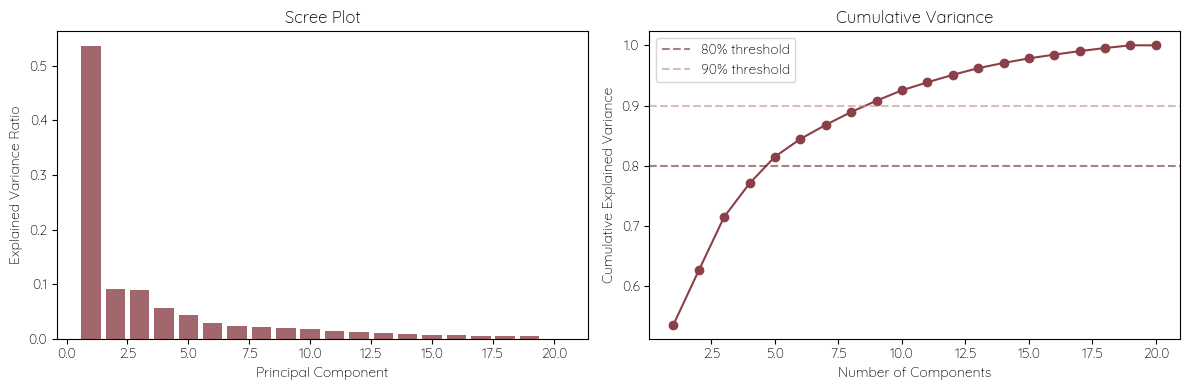

PC1: 0.536 (cumulative: 0.536)
PC2: 0.090 (cumulative: 0.627)
PC3: 0.089 (cumulative: 0.715)
PC4: 0.056 (cumulative: 0.771)
PC5: 0.044 (cumulative: 0.815)
PC6: 0.029 (cumulative: 0.845)
PC7: 0.023 (cumulative: 0.868)
PC8: 0.021 (cumulative: 0.889)
PC9: 0.019 (cumulative: 0.908)


In [2]:
# === PCA ===
pca_full = PCA().fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(range(1, len(pca_full.explained_variance_ratio_)+1),
        pca_full.explained_variance_ratio_, color='#8B4049', alpha=0.8)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Scree Plot')

ax2.plot(range(1, len(cumvar)+1), cumvar, 'o-', color='#8B4049')
ax2.axhline(y=0.8, color='#6B2D35', linestyle='--', alpha=0.6, label='80% threshold')
ax2.axhline(y=0.9, color='#C4918A', linestyle='--', alpha=0.6, label='90% threshold')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('Cumulative Variance')
ax2.legend()

plt.tight_layout()
plt.savefig('../outputs/scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()

for i, (var, cum) in enumerate(zip(pca_full.explained_variance_ratio_, cumvar)):
    if i < 5 or cum <= 0.91:
        print(f"PC{i+1}: {var:.3f} (cumulative: {cum:.3f})")


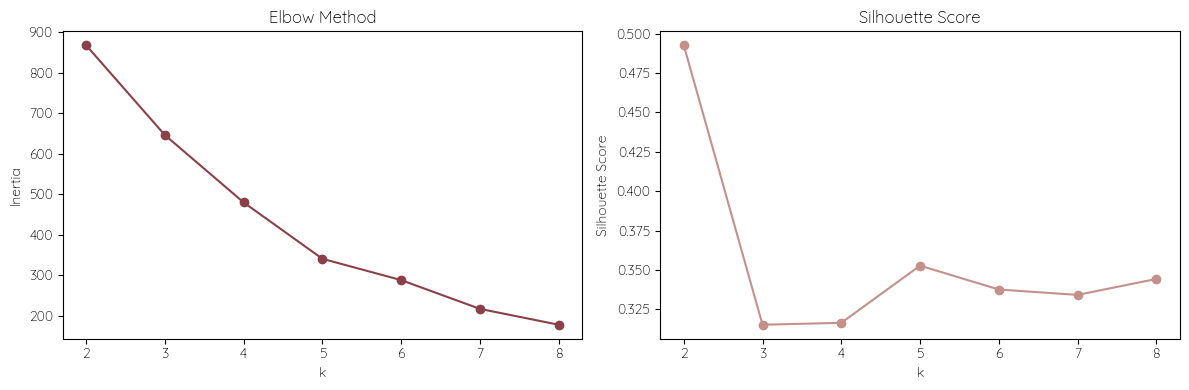

k=2: inertia=867.8, silhouette=0.493
k=3: inertia=645.9, silhouette=0.315
k=4: inertia=479.4, silhouette=0.316
k=5: inertia=340.1, silhouette=0.353
k=6: inertia=287.5, silhouette=0.338
k=7: inertia=216.4, silhouette=0.334
k=8: inertia=177.2, silhouette=0.344


In [3]:
# === K-Means: Elbow + Silhouette ===
pca2 = PCA(n_components=2).fit_transform(X_scaled)
pca5 = PCA(n_components=5).fit_transform(X_scaled)

K_range = range(2, 9)
inertias = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=42).fit(pca5)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(pca5, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(K_range, inertias, 'o-', color='#8B4049')
ax1.set_xlabel('k')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')

ax2.plot(K_range, sil_scores, 'o-', color='#C4918A')
ax2.set_xlabel('k')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')

plt.tight_layout()
plt.savefig('../outputs/elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

for k, iner, sil in zip(K_range, inertias, sil_scores):
    print(f"k={k}: inertia={iner:.1f}, silhouette={sil:.3f}")


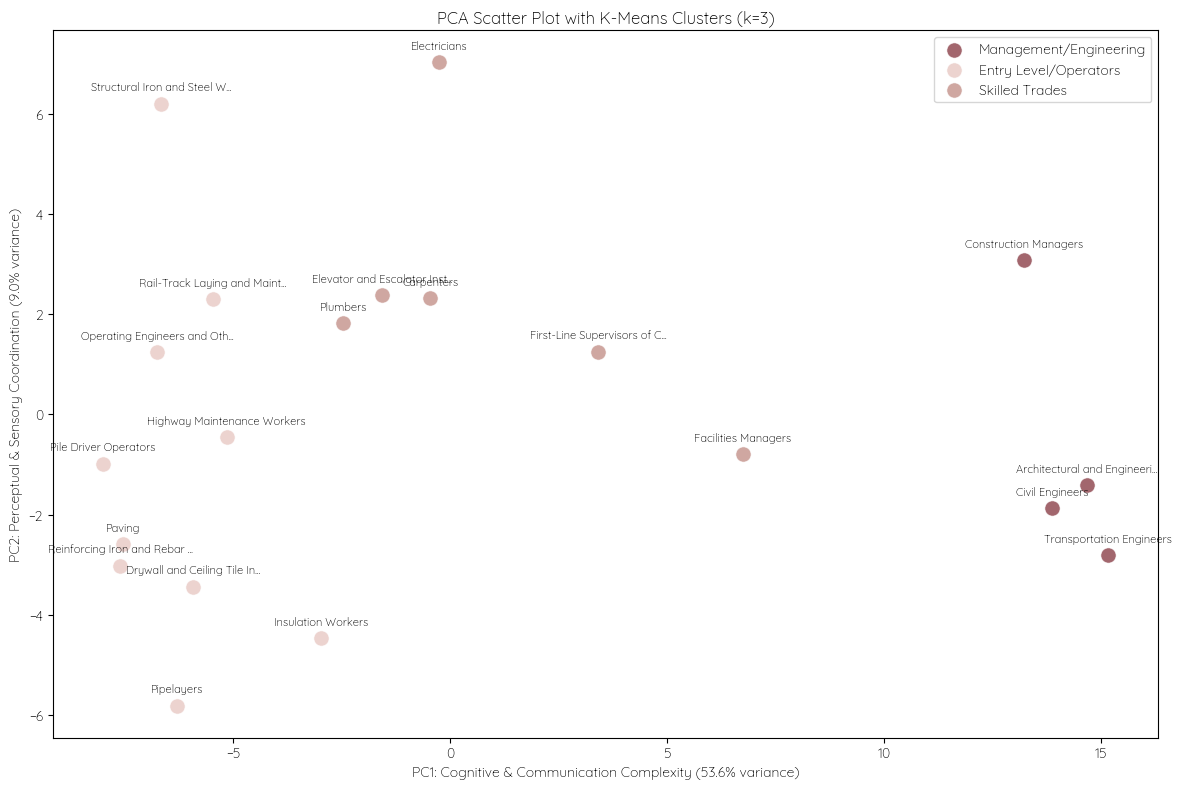

Cluster Contents:
Cluster 0 -- Management/Engineering (4 occ, avg JZ: 4.2):
  [4] Construction Managers
  [5] Architectural and Engineering Managers
  [4] Civil Engineers
  [4] Transportation Engineers
Cluster 1 -- Entry Level/Operators (10 occ, avg JZ: 2.0):
  [2] Paving, Surfacing, and Tamping Equipment Operators
  [2] Pile Driver Operators
  [2] Operating Engineers and Other Construction Equipment Operators
  [2] Drywall and Ceiling Tile Installers
  [2] Insulation Workers, Mechanical
  [2] Pipelayers
  [2] Reinforcing Iron and Rebar Workers
  [2] Structural Iron and Steel Workers
  [2] Highway Maintenance Workers
  [2] Rail-Track Laying and Maintenance Equipment Operators
Cluster 2 -- Skilled Trades (6 occ, avg JZ: 2.8):
  [3] Facilities Managers
  [3] First-Line Supervisors of Construction Trades and Extraction Workers
  [2] Carpenters
  [3] Electricians
  [3] Plumbers, Pipefitters, and Steamfitters
  [3] Elevator and Escalator Installers and Repairers


In [4]:
# === K-Means with k=3 + PCA Scatter ===
km3 = KMeans(n_clusters=3, n_init=20, random_state=42).fit(pca5)
labels = km3.labels_

# Cluster label -> name mapping (validated by Job Zone analysis: 0=Mgmt, 1=Entry, 2=Skilled)
cluster_label_names = {0: 'Management/Engineering', 1: 'Entry Level/Operators', 2: 'Skilled Trades'}
colors = [CLUSTER_COLORS['Management/Engineering'],
          CLUSTER_COLORS['Entry Level/Operators'],
          CLUSTER_COLORS['Skilled Trades']]

fig, ax = plt.subplots(figsize=(12, 8))
for cl in range(3):
    mask = labels == cl
    ax.scatter(pca2[mask, 0], pca2[mask, 1], c=colors[cl], s=120,
               alpha=0.8, edgecolors='white', linewidth=0.5, label=cluster_label_names[cl])

for i, (x, y) in enumerate(pca2):
    short = titles.iloc[i].split(',')[0]
    if len(short) > 30:
        short = short[:27] + '...'
    ax.annotate(short, (x, y), fontsize=8, ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points')

ax.set_xlabel(f'PC1: Cognitive & Communication Complexity ({pca_full.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2: Perceptual & Sensory Coordination ({pca_full.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('PCA Scatter Plot with K-Means Clusters (k=3)')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("Cluster Contents:")
for cl in range(3):
    mask = labels == cl
    members = titles[mask].tolist()
    jz_vals = job_zones[job_zones['O*NET-SOC Code'].isin(features.index[mask])]['Job Zone'].tolist()
    print(f"Cluster {cl} -- {cluster_label_names[cl]} ({sum(mask)} occ, avg JZ: {np.mean(jz_vals):.1f}):")
    for m, j in zip(members, jz_vals):
        print(f"  [{j}] {m}")


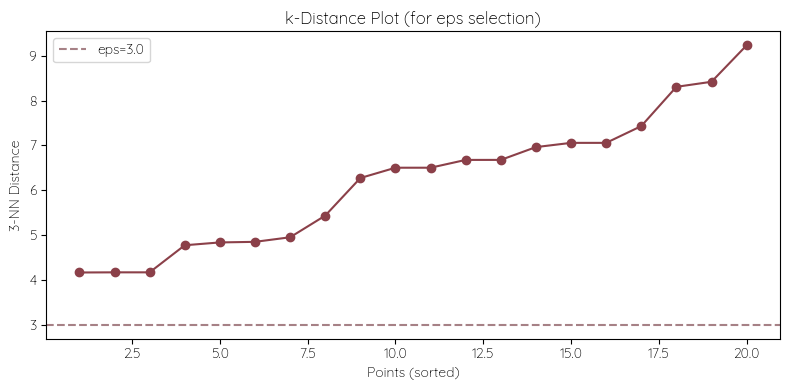

eps=2.5: 1 clusters, 18 noise points, silhouette=-1.000
eps=3.0: 1 clusters, 18 noise points, silhouette=-1.000
eps=3.5: 2 clusters, 16 noise points, silhouette=0.051
eps=4.0: 5 clusters, 10 noise points, silhouette=0.040


In [5]:
# === DBSCAN ===
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=3).fit(pca5)
distances, _ = nn.kneighbors(pca5)
k_dist = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(k_dist)+1), k_dist, 'o-', color='#8B4049')
ax.set_xlabel('Points (sorted)')
ax.set_ylabel('3-NN Distance')
ax.set_title('k-Distance Plot (for eps selection)')
ax.axhline(y=3.0, color='#6B2D35', linestyle='--', alpha=0.6, label='eps=3.0')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/kdist_plot.png', dpi=150, bbox_inches='tight')
plt.show()

for eps in [2.5, 3.0, 3.5, 4.0]:
    db = DBSCAN(eps=eps, min_samples=2).fit(pca5)
    n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    n_noise = list(db.labels_).count(-1)
    sil = silhouette_score(pca5, db.labels_) if n_clusters > 1 else -1
    print(f"eps={eps}: {n_clusters} clusters, {n_noise} noise points, silhouette={sil:.3f}")


eps=4.5: 4 clusters, 9 noise points, silhouette=0.145
eps=5.0: 4 clusters, 5 noise points, silhouette=0.244
eps=5.5: 4 clusters, 5 noise points, silhouette=0.244
eps=6.0: 4 clusters, 4 noise points, silhouette=0.287


/var/folders/sp/t1xddl3j5hb49dk8k_rp6qpr0000gn/T/ipykernel_70458/2140030409.py:33: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax2.scatter(pca2[mask, 0], pca2[mask, 1], c=color, s=120,


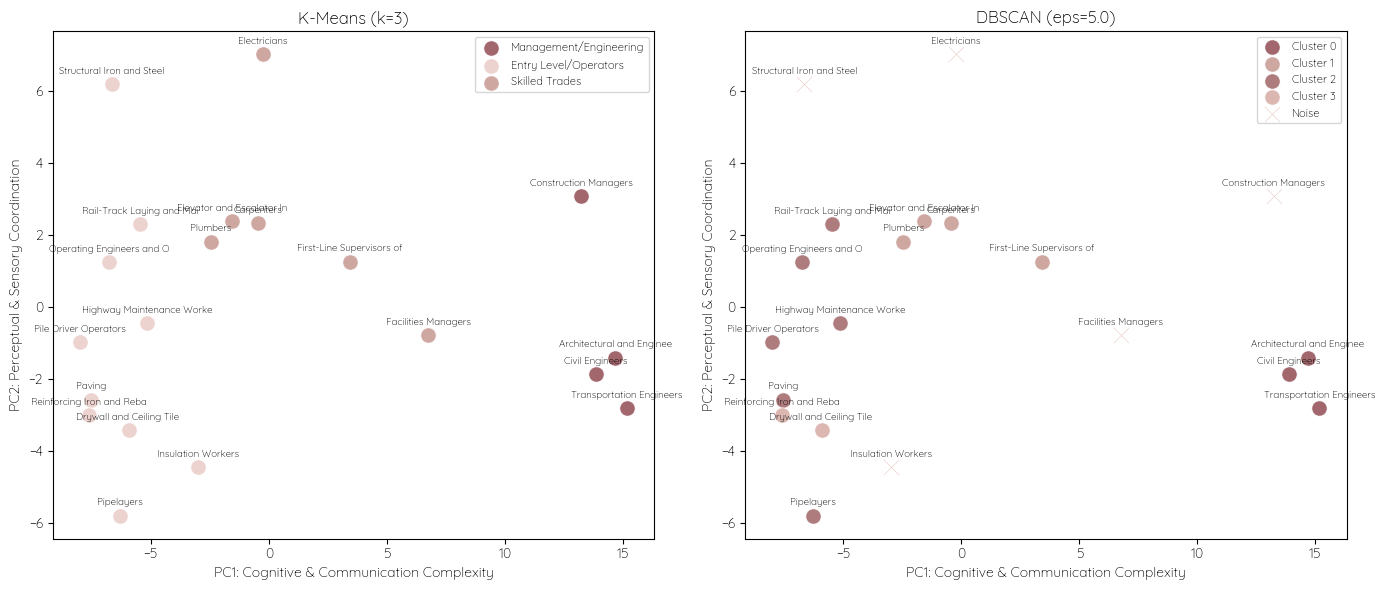

In [6]:
# === DBSCAN best attempt + comparison with K-Means ===
for eps in [4.5, 5.0, 5.5, 6.0]:
    db = DBSCAN(eps=eps, min_samples=2).fit(pca5)
    n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    n_noise = list(db.labels_).count(-1)
    sil = silhouette_score(pca5, db.labels_) if n_clusters > 1 else -1
    print(f"eps={eps}: {n_clusters} clusters, {n_noise} noise points, silhouette={sil:.3f}")

db_best = DBSCAN(eps=5.0, min_samples=2).fit(pca5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for cl in range(3):
    mask = labels == cl
    ax1.scatter(pca2[mask, 0], pca2[mask, 1], c=colors[cl], s=120,
                alpha=0.8, edgecolors='white', linewidth=0.5, label=cluster_label_names[cl])
    for i in np.where(mask)[0]:
        short = titles.iloc[i].split(',')[0][:25]
        ax1.annotate(short, (pca2[i,0], pca2[i,1]), fontsize=7, ha='center', va='bottom',
                     xytext=(0,6), textcoords='offset points')
ax1.set_title('K-Means (k=3)')
ax1.set_xlabel('PC1: Cognitive & Communication Complexity')
ax1.set_ylabel('PC2: Perceptual & Sensory Coordination')
ax1.legend(fontsize=8)

db_labels = db_best.labels_
unique_labels = set(db_labels)
db_colors = ['#8B4049', '#C4918A', '#9B5B5E', '#D4A59E', '#6B2D35', '#888888']
for cl in unique_labels:
    mask = db_labels == cl
    color = '#E8C8C3' if cl == -1 else db_colors[cl % len(db_colors)]
    label = 'Noise' if cl == -1 else f'Cluster {cl}'
    ax2.scatter(pca2[mask, 0], pca2[mask, 1], c=color, s=120,
                alpha=0.8, edgecolors='white', linewidth=0.5, label=label,
                marker='x' if cl == -1 else 'o')
    for i in np.where(mask)[0]:
        short = titles.iloc[i].split(',')[0][:25]
        ax2.annotate(short, (pca2[i,0], pca2[i,1]), fontsize=7, ha='center', va='bottom',
                     xytext=(0,6), textcoords='offset points')
ax2.set_title(f'DBSCAN (eps={db_best.eps})')
ax2.set_xlabel('PC1: Cognitive & Communication Complexity')
ax2.set_ylabel('PC2: Perceptual & Sensory Coordination')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/dbscan_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
# === Save cluster labels + validation summary ===
cluster_df = pd.DataFrame({
    'O*NET-SOC Code': features.index,
    'Title': titles.values,
    'cluster': labels,
    'Job Zone': job_zones.set_index('O*NET-SOC Code').loc[features.index, 'Job Zone'].values
})

# Name clusters based on what we found
cluster_map = {0: 'Management/Engineering', 1: 'Entry Level/Operators', 2: 'Skilled Trades'}
cluster_df['cluster_name'] = cluster_df['cluster'].map(cluster_map)

cluster_df.to_csv('../data/processed/cluster_labels.csv', index=False)
print("Saved cluster_labels.csv")
print(f"\n=== Validation: Cluster vs Job Zone ===")
print(cluster_df.groupby('cluster_name')['Job Zone'].agg(['mean', 'min', 'max', 'count']))

# Cosine similarity matrix (for Person B's network graph + Layer 3 recommendation)
from sklearn.metrics.pairwise import cosine_similarity
sim_matrix = cosine_similarity(X_scaled)
sim_df = pd.DataFrame(sim_matrix, index=features.index, columns=features.index)
sim_df.to_csv('../data/processed/cosine_similarity.csv')
print(f"\nSaved cosine_similarity.csv ({sim_df.shape})")

Saved cluster_labels.csv

=== Validation: Cluster vs Job Zone ===
                            mean  min  max  count
cluster_name                                     
Entry Level/Operators   2.000000    2    2     10
Management/Engineering  4.250000    4    5      4
Skilled Trades          2.833333    2    3      6

Saved cosine_similarity.csv ((20, 20))


In [8]:
# === Layer 3: Recommendation Prototype (fixed) ===

def recommend_occupations(user_skills: dict, top_n: int = 5):
    """
    Given a dict of {feature_name: score}, return top-N matching occupations.
    Only computes similarity on the dimensions the user specified.
    """
    # Get the feature columns the user actually filled in
    valid_features = [f for f in user_skills.keys() if f in X_raw.columns]
    if not valid_features:
        print("No valid features provided.")
        return None
    
    # Subset the raw data to only these features
    X_sub = X_raw[valid_features]
    user_vec = pd.Series(user_skills)[valid_features].values.reshape(1, -1)
    
    # Standardize both using the subset's stats
    from sklearn.preprocessing import StandardScaler
    sub_scaler = StandardScaler().fit(X_sub)
    X_sub_scaled = sub_scaler.transform(X_sub)
    user_sub_scaled = sub_scaler.transform(user_vec)
    
    # Cosine similarity on the subset
    sims = cosine_similarity(user_sub_scaled, X_sub_scaled)[0]
    
    results = pd.DataFrame({
        'Title': titles.values,
        'Cluster': cluster_df['cluster_name'].values,
        'Job Zone': cluster_df['Job Zone'].values,
        'Similarity': np.round(sims, 3)
    }, index=features.index).sort_values('Similarity', ascending=False)
    
    return results.head(top_n)

# === Test 1: Management/Engineering profile ===
print("=== Test: Management/Engineering profile ===")
user1 = {
    'skill_Critical Thinking': 4.0,
    'skill_Complex Problem Solving': 4.0,
    'skill_Coordination': 4.5,
    'skill_Judgment and Decision Making': 4.0,
    'knowledge_Administration and Management': 4.0,
    'knowledge_Engineering and Technology': 3.5,
    'knowledge_Mathematics': 3.5,
}
print(recommend_occupations(user1))

# === Test 2: Skilled trades profile ===
print("\n=== Test: Skilled trades profile ===")
user2 = {
    'skill_Equipment Maintenance': 4.0,
    'skill_Repairing': 4.0,
    'skill_Troubleshooting': 3.5,
    'skill_Operation and Control': 3.5,
    'knowledge_Building and Construction': 4.0,
    'knowledge_Mechanical': 4.0,
    'ability_Manual Dexterity': 4.0,
}
print(recommend_occupations(user2))

# === Test 3: Entry-level operator ===
print("\n=== Test: Entry-level operator profile ===")
user3 = {
    'skill_Operation and Control': 3.5,
    'skill_Operation Monitoring': 3.0,
    'ability_Control Precision': 3.5,
    'ability_Multilimb Coordination': 3.5,
    'knowledge_Transportation': 3.0,
}
print(recommend_occupations(user3))

=== Test: Management/Engineering profile ===
                                                            Title  \
O*NET-SOC Code                                                      
11-9021.00                                  Construction Managers   
11-9041.00                 Architectural and Engineering Managers   
11-3013.00                                    Facilities Managers   
47-1011.00      First-Line Supervisors of Construction Trades ...   
17-2051.01                               Transportation Engineers   

                               Cluster  Job Zone  Similarity  
O*NET-SOC Code                                                
11-9021.00      Management/Engineering         4       0.921  
11-9041.00      Management/Engineering         5       0.861  
11-3013.00              Skilled Trades         3       0.801  
47-1011.00              Skilled Trades         3       0.798  
17-2051.01      Management/Engineering         4       0.706  

=== Test: Skilled trades prof

/Users/josh/Projects/Python/School/DS5230/CareerDrive/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/josh/Projects/Python/School/DS5230/CareerDrive/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/josh/Projects/Python/School/DS5230/CareerDrive/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
